In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.0 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import shutil
from pathlib import Path

dataset1_zip = "/content/rock_dataset_split.zip"
dataset2_zip = "/content/rock-detection-wxs.v2-rock-wxs-v2.yolov11.zip"

dataset1_extract = "/content/dataset1"
dataset2_extract = "/content/dataset2"

for folder in [dataset1_extract, dataset2_extract]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

with zipfile.ZipFile(dataset1_zip, "r") as zip_ref:
    zip_ref.extractall(dataset1_extract)

with zipfile.ZipFile(dataset2_zip, "r") as zip_ref:
    zip_ref.extractall(dataset2_extract)


解压完成


In [ ]:
from pathlib import Path

dataset1_root = Path("/content/dataset1/rock_dataset_split")
dataset2_root = Path("/content/dataset2")
merged_root = Path("/content/rock_merged")

In [ ]:
merged_root = Path("/content/rock_merged")

if merged_root.exists():
    shutil.rmtree(merged_root)

for split in ["train", "valid", "test"]:
    (merged_root / split / "images").mkdir(parents=True, exist_ok=True)
    (merged_root / split / "labels").mkdir(parents=True, exist_ok=True)


新数据集目录建立完成


In [ ]:
def copy_yolo_split(
    source_images,
    source_labels,
    target_images,
    target_labels,
    prefix
):
    source_images = Path(source_images)
    source_labels = Path(source_labels)
    target_images = Path(target_images)
    target_labels = Path(target_labels)

    image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    copied_images = 0
    copied_labels = 0
    missing_labels = []

    for image_path in source_images.iterdir():
        if not image_path.is_file():
            continue

        if image_path.suffix.lower() not in image_extensions:
            continue

        new_image_name = prefix + image_path.name
        new_label_name = prefix + image_path.stem + ".txt"

        label_path = source_labels / f"{image_path.stem}.txt"

        shutil.copy2(
            image_path,
            target_images / new_image_name
        )
        copied_images += 1

        if label_path.exists():
            shutil.copy2(
                label_path,
                target_labels / new_label_name
            )
            copied_labels += 1
        else:
            missing_labels.append(image_path.name)

    return copied_images, copied_labels, missing_labels

In [ ]:
for split in ["train", "valid", "test"]:
    images_count, labels_count, missing = copy_yolo_split(
        source_images=dataset1_root / split / "images",
        source_labels=dataset1_root / split / "labels",
        target_images=merged_root / split / "images",
        target_labels=merged_root / split / "labels",
        prefix="dataset1_"
    )

    print(
        f"{split}: "
        f"images={images_count}, "
        f"labels={labels_count}, "
        f"missing_labels={len(missing)}"
    )

train: images=376, labels=376, missing_labels=0
valid: images=79, labels=79, missing_labels=0
test: images=78, labels=78, missing_labels=0


In [ ]:
images_count, labels_count, missing = copy_yolo_split(
    source_images=dataset2_root / "train/images",
    source_labels=dataset2_root / "train/labels",
    target_images=merged_root / "train/images",
    target_labels=merged_root / "train/labels",
    prefix="dataset2_"
)

print(
    f"Dataset2 train: "
    f"images={images_count}, "
    f"labels={labels_count}, "
    f"missing_labels={len(missing)}"
)

Dataset2 train: images=138, labels=138, missing_labels=0


In [ ]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "valid", "test"]:
    image_dir = merged_root / split / "images"
    label_dir = merged_root / split / "labels"

    image_count = sum(
        1 for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in image_extensions
    )

    label_count = len(list(label_dir.glob("*.txt")))

    print(
        f"{split}: images={image_count}, labels={label_count}"
    )

train: images=514, labels=514
valid: images=79, labels=79
test: images=78, labels=78


In [ ]:
yaml_content = f"""
path: {merged_root}

train: train/images
val: valid/images
test: test/images

names:
  0: ROCK
"""

yaml_path = merged_root / "data.yaml"

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_content.strip())

print(yaml_path.read_text())

path: /content/rock_merged

train: train/images
val: valid/images
test: test/images

names:
  0: ROCK


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="/content/rock_merged/data.yaml",

    epochs=80,
    imgsz=640,
    batch=16,
    device=0,

    project="/content/runs/rock_detection",
    name="yolo11n_merged_aug",
    exist_ok=True,

    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    patience=20,
    workers=2,

    degrees=10.0,
    translate=0.10,
    scale=0.30,
    shear=2.0,
    perspective=0.0002,

    fliplr=0.5,
    flipud=0.1,

    hsv_h=0.015,
    hsv_s=0.40,
    hsv_v=0.30,

    mosaic=0.5,
    mixup=0.0,
    close_mosaic=10,

    seed=42,
    deterministic=True,

    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock_merged/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1,

In [ ]:
best_model = YOLO(
    "/content/runs/rock_detection/yolo11n_merged_aug/weights/best.pt"
)

test_results = best_model.val(
    data="/content/rock_merged/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

print("Precision:", test_results.box.mp)
print("Recall:", test_results.box.mr)
print("mAP50:", test_results.box.map50)
print("mAP50-95:", test_results.box.map)

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3770.5±791.2 MB/s, size: 373.0 KB)
val: Scanning /content/rock_merged/test/labels... 78 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 2.2Kit/s 0.0s
val: New cache created: /content/rock_merged/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.0s
                   all         78         88      0.971      0.852      0.945      0.683
Speed: 8.9ms preprocess, 13.4ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/runs/detect/val
Precision: 0.9706626284824502
Recall: 0.8522727272727273
mAP50: 0.9445100975982783
mAP50-95: 0.6833874221096105


In [ ]:
from pathlib import Path

dataset_root = Path("/content/rock_merged")
label_dir = dataset_root / "train" / "labels"

label_files = list(label_dir.glob("*.txt"))

print("标签文件数量：", len(label_files))

for label_file in label_files[:5]:
    lines = label_file.read_text().strip().splitlines()

    print("\n文件：", label_file.name)

    for line in lines[:3]:
        values = line.split()
        print(len(values))
        print(line[:150])

标签文件数量： 514

文件： dataset1_Sunny_GreenGrass_Mz_June_2025-53-_JPG.rf.e9d59d81236dafaa94bcc38e05ea7914.txt
数值数量： 5
0 0.53173828125 0.3388671875 0.27880859375 0.26416015625

文件： dataset1_IMG_9998_jpeg.rf.b78ce1826ddbd747717f00f1075e1349.txt
数值数量： 5
0 0.52099609375 0.46923828125 0.2421875 0.16455078125

文件： dataset1_Sunny_Dirt_20250516_080532_jpg.rf.17111d331c55ad53c25a30fddabef1d7.txt
数值数量： 5
0 0.55712890625 0.408203125 0.16162109375 0.189453125

文件： dataset1_IMG_0063_jpeg.rf.a3eace580773ec382037b7a3fa87ac09.txt
数值数量： 5
0 0.5654296875 0.716796875 0.18994140625 0.0703125

文件： dataset1_Stone007_view1_jpeg.rf.642cd37a8da5e0df575387edd475353b.txt


In [ ]:
from pathlib import Path

dataset_root = Path("/content/rock_merged")

for split in ["train", "valid", "test"]:
    image_dir = dataset_root / split / "images"
    label_dir = dataset_root / split / "labels"

    image_count = (
        len(list(image_dir.glob("*.jpg")))
        + len(list(image_dir.glob("*.jpeg")))
        + len(list(image_dir.glob("*.png")))
    )

    label_count = len(list(label_dir.glob("*.txt")))

    print(
        f"{split}: "
        f"{image_count} images, "
        f"{label_count} labels"
    )

train: 514 images, 514 labels
valid: 79 images, 79 labels
test: 78 images, 78 labels


In [ ]:
from pathlib import Path

dataset_root = Path("/content/rock_merged")
seg_yaml_path = Path("/content/rock_seg.yaml")

yaml_content = f"""
path: {dataset_root}

train: train/images
val: valid/images
test: test/images

names:
  0: rock
"""

seg_yaml_path.write_text(yaml_content.strip())

print(seg_yaml_path.read_text())

path: /content/rock_merged

train: train/images
val: valid/images
test: test/images

names:
  0: rock


！！！进行实验

In [ ]:
!pip install -U ultralytics opencv-python

In [ ]:
import torch
import ultralytics

print("Ultralytics version:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Ultralytics version: 8.4.107
CUDA available: True
GPU: Tesla T4


In [ ]:
from ultralytics import SAM

sam_model = SAM("mobile_sam.pt")

print("MobileSAM 加载完成")

MobileSAM 加载完成


In [ ]:
from pathlib import Path
import shutil

source_root = Path("/content/rock_merged")
seg_root = Path("/content/rock_merged_seg")

if seg_root.exists():
    shutil.rmtree(seg_root)

for split in ["train", "valid", "test"]:
    source_images = source_root / split / "images"
    target_images = seg_root / split / "images"
    target_labels = seg_root / split / "labels"

    shutil.copytree(source_images, target_images)
    target_labels.mkdir(parents=True, exist_ok=True)


新数据集已建立： /content/rock_merged_seg


In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

source_root = Path("/content/rock_merged")

image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

train_images_dir = source_root / "train" / "images"
train_labels_dir = source_root / "train" / "labels"

image_files = [
    p for p in train_images_dir.iterdir()
    if p.suffix.lower() in image_extensions
]

test_image_path = image_files[0]
test_label_path = train_labels_dir / f"{test_image_path.stem}.txt"


测试图片： /content/rock_merged/train/images/dataset1_Stone013_view2_jpeg.rf.a232dd1d24b5814d5c6f0ae2c467ef08.jpg
对应标签： /content/rock_merged/train/labels/dataset1_Stone013_view2_jpeg.rf.a232dd1d24b5814d5c6f0ae2c467ef08.txt


In [ ]:
image = cv2.imread(str(test_image_path))

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
height, width = image.shape[:2]

boxes = []
class_ids = []

with open(test_label_path, "r") as f:
    for line in f:
        values = line.strip().split()

        if len(values) != 5:
            continue

        class_id, x_center, y_center, box_width, box_height = map(float, values)

        x_center *= width
        y_center *= height
        box_width *= width
        box_height *= height

        x1 = x_center - box_width / 2
        y1 = y_center - box_height / 2
        x2 = x_center + box_width / 2
        y2 = y_center + box_height / 2

        x1 = max(0, min(width - 1, x1))
        y1 = max(0, min(height - 1, y1))
        x2 = max(0, min(width - 1, x2))
        y2 = max(0, min(height - 1, y2))

        boxes.append([x1, y1, x2, y2])
        class_ids.append(int(class_id))

print("size：", width, "×", height)
print("number：", len(boxes))
print("Bounding boxes：", boxes)

图片尺寸： 1024 × 1024
石头数量： 1
Bounding boxes： [[474.25, 442.5, 663.75, 595.5]]


In [ ]:
sam_results = sam_model(
    source=str(test_image_path),
    bboxes=boxes,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False
)

result = sam_results[0]

print("是否生成 mask：", result.masks is not None)

if result.masks is not None:
    print("mask 数量：", len(result.masks.data))

是否生成 mask： True
mask 数量： 1


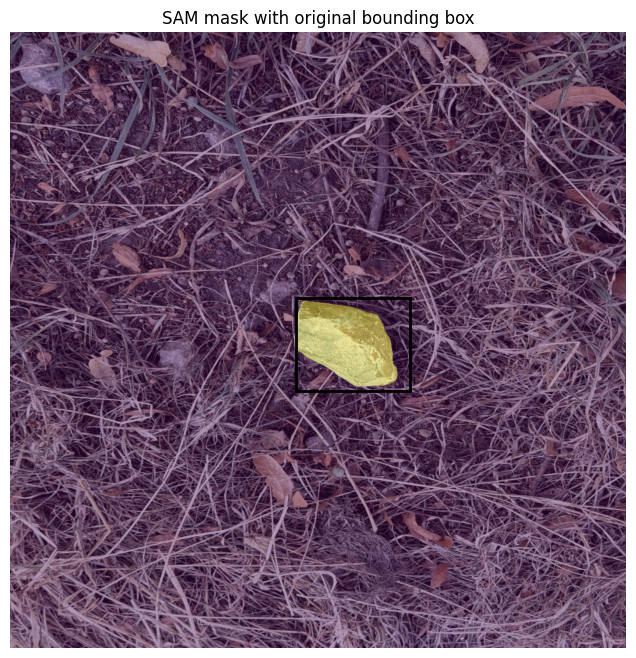

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)

if result.masks is not None:
    masks = result.masks.data.cpu().numpy()

    for mask in masks:
        plt.imshow(mask, alpha=0.4)

for box in boxes:
    x1, y1, x2, y2 = box

    rectangle = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )

    plt.gca().add_patch(rectangle)

plt.axis("off")
plt.title("SAM mask with original bounding box")
plt.show()

正式SAM

In [ ]:
!pip install -U ultralytics opencv-python tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 8.8 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
      Successfully uninstalled tqdm-4.67.3


In [ ]:
from ultralytics import SAM
import torch

device = 0 if torch.cuda.is_available() else "cpu"

sam_model = SAM("mobile_sam.pt")

print("Device:", device)
print("SAM loaded successfully")

Device: 0
SAM loaded successfully


In [ ]:
from pathlib import Path
import shutil
import cv2
import numpy as np
import torch
from tqdm.auto import tqdm

SOURCE_ROOT = Path("/content/rock_merged")
TARGET_ROOT = Path("/content/rock_merged_seg")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

DEVICE = 0 if torch.cuda.is_available() else "cpu"

MAX_IMAGES_PER_SPLIT = None
MIN_CONTOUR_AREA = 20
POLYGON_EPSILON_RATIO = 0.002
MIN_POLYGON_POINTS = 3

RESET_TARGET_DATASET = True


def read_yolo_boxes(label_path, image_width, image_height):


    boxes = []
    class_ids = []

    if not label_path.exists():
        return boxes, class_ids

    lines = label_path.read_text().strip().splitlines()

    for line_number, line in enumerate(lines, start=1):
        values = line.strip().split()

        if len(values) != 5:
            print(
                f"skip the wrong labels：{label_path.name}，"
                f" {line_number}  {len(values)} "
            )
            continue

        try:
            class_id = int(float(values[0]))
            x_center = float(values[1])
            y_center = float(values[2])
            box_width = float(values[3])
            box_height = float(values[4])
        except ValueError:
            print(
                f"skip：{label_path.name}，"
                f" {line_number} "
            )
            continue

        x_center *= image_width
        y_center *= image_height
        box_width *= image_width
        box_height *= image_height

        x1 = x_center - box_width / 2
        y1 = y_center - box_height / 2
        x2 = x_center + box_width / 2
        y2 = y_center + box_height / 2

        x1 = max(0, min(image_width - 1, x1))
        y1 = max(0, min(image_height - 1, y1))
        x2 = max(0, min(image_width - 1, x2))
        y2 = max(0, min(image_height - 1, y2))

        if x2 <= x1 or y2 <= y1:
            print(f"skip：{label_path.name}")
            continue

        boxes.append([x1, y1, x2, y2])
        class_ids.append(class_id)

    return boxes, class_ids



def mask_to_polygon(
    mask,
    image_width,
    image_height,
    min_contour_area=20,
    epsilon_ratio=0.002
):


    mask = np.asarray(mask)

    if mask.shape[:2] != (image_height, image_width):
        mask = cv2.resize(
            mask.astype(np.float32),
            (image_width, image_height),
            interpolation=cv2.INTER_NEAREST
        )

    binary_mask = (mask > 0.5).astype(np.uint8) * 255

    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if not contours:
        return None

    valid_contours = [
        contour
        for contour in contours
        if cv2.contourArea(contour) >= min_contour_area
    ]

    if not valid_contours:
        return None

    largest_contour = max(valid_contours, key=cv2.contourArea)

    perimeter = cv2.arcLength(largest_contour, True)
    epsilon = epsilon_ratio * perimeter

    simplified_contour = cv2.approxPolyDP(
        largest_contour,
        epsilon,
        True
    )

    points = simplified_contour.reshape(-1, 2)

    if len(points) < MIN_POLYGON_POINTS:
        return None

    polygon = []

    for x, y in points:
        normalized_x = float(x) / image_width
        normalized_y = float(y) / image_height

        normalized_x = min(max(normalized_x, 0.0), 1.0)
        normalized_y = min(max(normalized_y, 0.0), 1.0)

        polygon.extend([normalized_x, normalized_y])

    return polygon


def process_single_image(
    image_path,
    source_label_path,
    target_label_path,
    sam_model
):


    image = cv2.imread(str(image_path))

    if image is None:
        return {
            "status": "failed",
            "reason": "image_read_failed",
            "instances": 0
        }

    image_height, image_width = image.shape[:2]

    boxes, class_ids = read_yolo_boxes(
        source_label_path,
        image_width,
        image_height
    )

    if not boxes:
        target_label_path.write_text("")
        return {
            "status": "empty",
            "reason": "no_boxes",
            "instances": 0
        }

    try:
        sam_results = sam_model(
            source=str(image_path),
            bboxes=boxes,
            device=DEVICE,
            verbose=False
        )
    except Exception as error:
        return {
            "status": "failed",
            "reason": f"sam_error: {error}",
            "instances": 0
        }

    if not sam_results:
        return {
            "status": "failed",
            "reason": "no_sam_results",
            "instances": 0
        }

    result = sam_results[0]

    if result.masks is None:
        return {
            "status": "failed",
            "reason": "no_masks",
            "instances": 0
        }

    masks = result.masks.data.cpu().numpy()
    usable_count = min(
        len(masks),
        len(class_ids)
    )

    segmentation_lines = []
    failed_instances = 0

    for instance_index in range(usable_count):
        mask = masks[instance_index]
        class_id = class_ids[instance_index]

        polygon = mask_to_polygon(
            mask=mask,
            image_width=image_width,
            image_height=image_height,
            min_contour_area=MIN_CONTOUR_AREA,
            epsilon_ratio=POLYGON_EPSILON_RATIO
        )

        if polygon is None:
            failed_instances += 1
            continue

        coordinates = " ".join(
            f"{coordinate:.6f}"
            for coordinate in polygon
        )

        segmentation_lines.append(
            f"{class_id} {coordinates}"
        )

    target_label_path.write_text(
        "\n".join(segmentation_lines)
    )

    if len(segmentation_lines) == 0:
        return {
            "status": "failed",
            "reason": "all_polygons_failed",
            "instances": 0
        }

    return {
        "status": "success",
        "reason": "",
        "instances": len(segmentation_lines),
        "failed_instances": failed_instances,
        "expected_instances": len(boxes)
    }



def prepare_target_dataset():
    if not SOURCE_ROOT.exists():
        raise FileNotFoundError(
            f"cannot find：{SOURCE_ROOT}"
        )

    if TARGET_ROOT.exists() and RESET_TARGET_DATASET:
        shutil.rmtree(TARGET_ROOT)

    TARGET_ROOT.mkdir(parents=True, exist_ok=True)

    for split in ["train", "valid", "test"]:
        source_images_dir = SOURCE_ROOT / split / "images"
        target_images_dir = TARGET_ROOT / split / "images"
        target_labels_dir = TARGET_ROOT / split / "labels"

        if not source_images_dir.exists():
            print(f"cannot find {source_images_dir}")
            continue

        if not target_images_dir.exists():
            shutil.copytree(
                source_images_dir,
                target_images_dir
            )

        target_labels_dir.mkdir(
            parents=True,
            exist_ok=True
        )


def convert_split(split, sam_model, max_images=None):
    source_images_dir = SOURCE_ROOT / split / "images"
    source_labels_dir = SOURCE_ROOT / split / "labels"
    target_labels_dir = TARGET_ROOT / split / "labels"

    image_paths = sorted([
        path
        for path in source_images_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ])

    if max_images is not None:
        image_paths = image_paths[:max_images]

    statistics = {
        "images_total": len(image_paths),
        "images_success": 0,
        "images_empty": 0,
        "images_failed": 0,
        "instances_created": 0
    }

    failure_records = []

    for image_path in tqdm(
        image_paths,
        desc=f"Converting {split}"
    ):
        source_label_path = (
            source_labels_dir /
            f"{image_path.stem}.txt"
        )

        target_label_path = (
            target_labels_dir /
            f"{image_path.stem}.txt"
        )

        result = process_single_image(
            image_path=image_path,
            source_label_path=source_label_path,
            target_label_path=target_label_path,
            sam_model=sam_model
        )

        if result["status"] == "success":
            statistics["images_success"] += 1
            statistics["instances_created"] += result["instances"]

        elif result["status"] == "empty":
            statistics["images_empty"] += 1

        else:
            statistics["images_failed"] += 1

            failure_records.append(
                f"{image_path.name}\t{result['reason']}"
            )

    failure_log_path = (
        TARGET_ROOT /
        f"{split}_conversion_failures.txt"
    )

    failure_log_path.write_text(
        "\n".join(failure_records)
    )

    return statistics



prepare_target_dataset()

all_statistics = {}

for split in ["train", "valid", "test"]:
    print(f"\nstarting：{split}")

    split_statistics = convert_split(
        split=split,
        sam_model=sam_model,
        max_images=MAX_IMAGES_PER_SPLIT
    )

    all_statistics[split] = split_statistics

    print(f"{split} results：")
    for key, value in split_statistics.items():
        print(f"  {key}: {value}")


print("\finished")

for split, statistics in all_statistics.items():
    print(f"\n{split}:")
    print(statistics)

目标数据集已建立： /content/rock_merged_seg

开始处理：train


Converting train:   0%|          | 0/514 [00:00<?, ?it/s]

train 转换结果：
  images_total: 514
  images_success: 510
  images_empty: 4
  images_failed: 0
  instances_created: 775

开始处理：valid


Converting valid:   0%|          | 0/79 [00:00<?, ?it/s]

valid 转换结果：
  images_total: 79
  images_success: 79
  images_empty: 0
  images_failed: 0
  instances_created: 85

开始处理：test


Converting test:   0%|          | 0/78 [00:00<?, ?it/s]

test 转换结果：
  images_total: 78
  images_success: 78
  images_empty: 0
  images_failed: 0
  instances_created: 88

全部转换完成

train:
{'images_total': 514, 'images_success': 510, 'images_empty': 4, 'images_failed': 0, 'instances_created': 775}

valid:
{'images_total': 79, 'images_success': 79, 'images_empty': 0, 'images_failed': 0, 'instances_created': 85}

test:
{'images_total': 78, 'images_success': 78, 'images_empty': 0, 'images_failed': 0, 'instances_created': 88}


In [ ]:
from pathlib import Path

seg_label_dir = Path(
    "/content/rock_merged_seg/train/labels"
)

seg_label_files = list(seg_label_dir.glob("*.txt"))

print("the number of labels：", len(seg_label_files))

for label_path in seg_label_files[:5]:
    print("\nfile：", label_path.name)

    lines = label_path.read_text().strip().splitlines()

    if not lines:
        print("none")
        continue

    for line in lines[:2]:
        values = line.split()

        print("the number：", len(values))
        print(line[:250])

已生成标签数量： 514

文件： dataset1_Sunny_GreenGrass_Mz_June_2025-53-_JPG.rf.e9d59d81236dafaa94bcc38e05ea7914.txt
数值数量： 103
0 0.654297 0.285156 0.630859 0.264648 0.601562 0.264648 0.598633 0.259766 0.603516 0.258789 0.604492 0.250977 0.595703 0.249023 0.590820 0.250977 0.586914 0.244141 0.583984 0.245117 0.576172 0.238281 0.574219 0.228516 0.564453 0.216797 0.548828 0.210

文件： dataset1_IMG_9998_jpeg.rf.b78ce1826ddbd747717f00f1075e1349.txt
数值数量： 61
0 0.456055 0.387695 0.445312 0.403320 0.439453 0.421875 0.434570 0.430664 0.424805 0.468750 0.420898 0.474609 0.414062 0.479492 0.407227 0.490234 0.405273 0.509766 0.409180 0.514648 0.437500 0.517578 0.450195 0.516602 0.454102 0.519531 0.490234 0.519

文件： dataset1_Sunny_Dirt_20250516_080532_jpg.rf.17111d331c55ad53c25a30fddabef1d7.txt
数值数量： 89
0 0.528320 0.317383 0.520508 0.321289 0.505859 0.350586 0.498047 0.361328 0.493164 0.377930 0.489258 0.383789 0.490234 0.390625 0.485352 0.391602 0.485352 0.396484 0.481445 0.399414 0.482422 0.409180 0.477539 0.4

In [ ]:
from pathlib import Path

seg_root = Path("/content/rock_merged_seg")

for split in ["train", "valid", "test"]:
    label_dir = seg_root / split / "labels"

    label_files = list(label_dir.glob("*.txt"))
    empty_files = [
        path for path in label_files
        if not path.read_text().strip()
    ]

    print(f"\n{split}")
    print("the whole number：", len(label_files))
    print("the number of blank：", len(empty_files))

    for path in empty_files[:20]:
        print("  ", path.name)


train
标签总数： 514
空标签数量： 4
   dataset1_Stone007_view1_jpeg.rf.642cd37a8da5e0df575387edd475353b.txt
   dataset2_Stone007_view1_jpeg.rf.642cd37a8da5e0df575387edd475353b.txt
   dataset2_Stone007_view2_jpeg.rf.3cc860f3c9d20d64ab372bfbc7f9332d.txt
   dataset1_Stone007_view2_jpeg.rf.3cc860f3c9d20d64ab372bfbc7f9332d.txt

valid
标签总数： 79
空标签数量： 0

test
标签总数： 78
空标签数量： 0


In [ ]:
from pathlib import Path

source_root = Path("/content/rock_merged")
seg_root = Path("/content/rock_merged_seg")


def count_detection_instances(label_path):
    if not label_path.exists():
        return 0

    lines = [
        line for line in label_path.read_text().splitlines()
        if line.strip()
    ]

    return sum(
        1 for line in lines
        if len(line.split()) == 5
    )


def count_segmentation_instances(label_path):
    if not label_path.exists():
        return 0

    lines = [
        line for line in label_path.read_text().splitlines()
        if line.strip()
    ]

    return sum(
        1 for line in lines
        if len(line.split()) >= 7
        and len(line.split()) % 2 == 1
    )


all_problem_records = []

for split in ["train", "valid", "test"]:
    source_label_dir = source_root / split / "labels"
    seg_label_dir = seg_root / split / "labels"

    source_labels = sorted(source_label_dir.glob("*.txt"))

    source_instances_total = 0
    seg_instances_total = 0
    mismatch_count = 0

    for source_label in source_labels:
        seg_label = seg_label_dir / source_label.name

        source_count = count_detection_instances(source_label)
        seg_count = count_segmentation_instances(seg_label)

        source_instances_total += source_count
        seg_instances_total += seg_count

        if source_count != seg_count:
            mismatch_count += 1
            all_problem_records.append({
                "split": split,
                "filename": source_label.name,
                "detection_instances": source_count,
                "segmentation_instances": seg_count
            })

    print(f"\n{split}")
    print("bbox：", source_instances_total)
    print("polygon：", seg_instances_total)
    print("mis match：", mismatch_count)


for record in all_problem_records[:30]:
    print(record)


train
原始 bbox 实例总数： 775
生成 polygon 实例总数： 775
实例数量不一致的图片： 0

valid
原始 bbox 实例总数： 85
生成 polygon 实例总数： 85
实例数量不一致的图片： 0

test
原始 bbox 实例总数： 88
生成 polygon 实例总数： 88
实例数量不一致的图片： 0

前 30 个问题文件：


###正式训练


In [ ]:
from pathlib import Path

seg_root = Path("/content/rock_merged_seg")
yaml_path = Path("/content/rock_seg.yaml")

yaml_content = f"""
path: {seg_root}

train: train/images
val: valid/images
test: test/images

names:
  0: rock
"""

yaml_path.write_text(yaml_content.strip())

print(yaml_path.read_text())

path: /content/rock_merged_seg

train: train/images
val: valid/images
test: test/images

names:
  0: rock


In [ ]:
from ultralytics import YOLO
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = YOLO("yolo11n-seg.pt")

train_results = model.train(
    data="/content/rock_seg.yaml",

    epochs=100,
    patience=20,

    imgsz=640,
    batch=16,
    device=0 if torch.cuda.is_available() else "cpu",
    workers=2,

    project="/content/runs/rock_seg",
    name="yolo11n_seg_sam",
    exist_ok=True,

    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    seed=42,
    deterministic=True,

    degrees=10.0,
    translate=0.1,
    scale=0.3,
    fliplr=0.5,
    flipud=0.0,

    mosaic=0.5,
    mixup=0.0,
    close_mosaic=10,

    cache=False,
    save=True,
    plots=True,
    verbose=True
)

CUDA available: True
GPU: Tesla T4
Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock_seg.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, na

In [ ]:
from ultralytics import YOLO
from pathlib import Path

best_path = Path(
    "/content/runs/rock_seg/"
    "yolo11n_seg_sam/weights/best.pt"
)


best_model = YOLO(str(best_path))

test_metrics = best_model.val(
    data="/content/rock_seg.yaml",
    split="test",
    imgsz=640,
    batch=8,
    device=0 if torch.cuda.is_available() else "cpu",
    plots=True,

    project="/content/runs/rock_seg",
    name="yolo11n_seg_test"
)

best.pt 是否存在： True
模型路径： /content/runs/rock_seg/yolo11n_seg_sam/weights/best.pt
Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2819.0±633.7 MB/s, size: 363.2 KB)
val: Scanning /content/rock_merged_seg/test/labels... 78 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 630.5it/s 0.1s
val: New cache created: /content/rock_merged_seg/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.4it/s 4.2s
                   all         78         88       0.96      0.909      0.966      0.871       0.96      0.909      0.958       0.85
Speed: 8.2ms preprocess, 15.4ms inference, 0.0ms loss, 6.0ms postprocess per image
Results saved to /content/runs/rock_seg/yolo11n_seg_test


In [ ]:
from ultralytics import YOLO
import torch

model = YOLO("/content/runs/rock_seg/yolo11n_seg_sam/weights/best.pt")

model.predict(
    source="/content/rock_merged_seg/test/images",
    imgsz=640,
    conf=0.25,
    device=0 if torch.cuda.is_available() else "cpu",
    save=True,
    project="/content/runs/rock_seg",
    name="test_predictions",
    exist_ok=True
)


image 1/78 /content/rock_merged_seg/test/images/dataset1_Cloudy_Dirt_20250617_113910_jpg.rf.bbea7fa0002b1511d43bfa9b8f35e1bc.jpg: 640x640 1 rock, 13.2ms
image 2/78 /content/rock_merged_seg/test/images/dataset1_Cloudy_Dirt_20250617_113916_jpg.rf.dd72437a34b829e6e0dcd1583ea71642.jpg: 640x640 1 rock, 13.5ms
image 3/78 /content/rock_merged_seg/test/images/dataset1_Cloudy_Dirt_20250617_124950_jpg.rf.df39c39b8e8a591d3e3f6b06c79dee15.jpg: 640x640 1 rock, 15.3ms
image 4/78 /content/rock_merged_seg/test/images/dataset1_Cloudy_Dirt_20250617_124958_jpg.rf.799096991a604f1d7a689bba70b99097.jpg: 640x640 1 rock, 15.9ms
image 5/78 /content/rock_merged_seg/test/images/dataset1_Cloudy_Dirt_20250617_125003_jpg.rf.51f37dbfeec5caa522c26e7026464034.jpg: 640x640 1 rock, 13.0ms
image 6/78 /content/rock_merged_seg/test/images/dataset1_Cloudy_Dirt_20250617_125014_jpg.rf.cf0a043cb0a049cce2968905968f7f6d.jpg: 640x640 1 rock, 13.9ms
image 7/78 /content/rock_merged_seg/test/images/dataset1_Cloudy_Dirt_20250617_131

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'rock'}
 obb: None
 orig_img: array([[[167, 240, 224],
         [159, 231, 219],
         [158, 224, 219],
         ...,
         [  5,  55,  45],
         [ 57, 103,  91],
         [ 67, 113, 101]],
 
        [[141, 218, 204],
         [131, 207, 195],
         [129, 199, 193],
         ...,
         [ 42,  92,  80],
         [ 72, 120, 108],
         [ 88, 136, 124]],
 
        [[100, 185, 171],
         [ 90, 174, 162],
         [ 89, 166, 162],
         ...,
         [ 63, 117, 104],
         [ 68, 121, 108],
         [ 97, 148, 134]],
 
        ...,
 
        [[ 40, 107,  80],
         [ 38, 105,  78],
         [ 35, 100,  74],
         ...,
         [ 31,  49,  66],
         [ 32,  53,  68],
         [ 31,  53,  65]],
 
        [[ 34, 108,  78],
         [ 33, 107,  77],
         [ 3